In [3]:
import numpy as np
import pandas as pd
import os

In [5]:
os.chdir('../')

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

raw_data = pd.read_csv("Datasets/jpm_cluster.csv",na_values=' ')
raw_data.columns = ['id','performance','fees_commissions','depth_of_products','ability_resolve_problems','online_services','choice_of_providers','quality_of_advice','knowledge_of_reps','rep_knowing_your_needs','professional_services','provider_knows_me','quality_of_service',
                'age','marital_status','education']
data = raw_data.copy()
data.head()

,id,performance,fees_commissions,depth_of_products,ability_resolve_problems,online_services,choice_of_providers,quality_of_advice,knowledge_of_reps,rep_knowing_your_needs,professional_services,provider_knows_me,quality_of_service,age,marital_status,education
0,1,3.0,3.0,NaN,5.0,1.0,3.0,5.0,5.0,5.0,4.0,5.0,4.0,3.0,1.0,2.0
1,2,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0,2.0,1.0,1.0
2,3,5.0,5.0,3.0,2.0,3.0,1.0,5.0,5.0,2.0,2.0,4.0,5.0,1.0,1.0,5.0
3,4,5.0,3.0,5.0,5.0,4.0,4.0,4.0,5.0,5.0,4.0,5.0,5.0,2.0,1.0,3.0
4,5,5.0,5.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,1.0,2.0


In [8]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data)

In [10]:
data_imputed

array([[  1.        ,   3.        ,   3.        , ...,   3.        ,
          1.        ,   2.        ],
       [  2.        ,   4.29912664,   3.77896996, ...,   2.        ,
          1.        ,   1.        ],
       [  3.        ,   5.        ,   5.        , ...,   1.        ,
          1.        ,   5.        ],
       ...,
       [498.        ,   5.        ,   4.        , ...,   2.        ,
          1.        ,   5.        ],
       [499.        ,   4.        ,   2.        , ...,   4.        ,
          1.        ,   3.        ],
       [500.        ,   5.        ,   1.        , ...,   3.        ,
          1.        ,   5.        ]], shape=(500, 16))

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_prepared = scaler.fit_transform(data_imputed)

In [12]:
pd.DataFrame(data_prepared).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-1.728590,-1.510164,-9.077031e-01,0.000000,1.154034e+00,-1.318845e+00,-0.351999,0.851054,0.872221,0.986287,0.578088,1.275791,-0.685324,0.229596,-0.401191,-1.033494
1,-1.721662,0.000000,5.174797e-16,0.239794,-4.859126e-16,3.590216e-16,0.000000,0.000000,-0.225864,0.000000,0.000000,0.000000,-0.685324,-0.812251,-0.401191,-1.685945
2,-1.714734,0.814727,1.422818e+00,-0.851267,-2.128499e+00,2.980442e-01,-2.227924,0.851054,0.872221,-1.972575,-1.413349,0.325646,0.839440,-1.854098,-0.401191,0.923861
3,-1.707806,0.814727,-9.077031e-01,1.330855,1.154034e+00,1.106489e+00,0.585963,-0.290419,0.872221,0.986287,0.578088,1.275791,0.839440,-0.812251,-0.401191,-0.381042
4,-1.700877,0.814727,1.422818e+00,0.239794,5.985656e-02,1.106489e+00,1.523925,0.851054,0.872221,0.986287,0.578088,1.275791,-0.685324,1.271443,-0.401191,-1.033494


In [13]:
from scipy.spatial.distance import pdist, squareform
dist_matrix = pdist(data_prepared, metric = 'euclidean')
squareform(np.round(dist_matrix,1))

array([[0. , 3.6, 7.3, ..., 5.6, 5.6, 6.8],
       [3.6, 0. , 5.6, ..., 5.6, 5.1, 6.9],
       [7.3, 5.6, 0. , ..., 6.7, 7.1, 9.4],
       ...,
       [5.6, 5.6, 6.7, ..., 0. , 5. , 5.1],
       [5.6, 5.1, 7.1, ..., 5. , 0. , 5. ],
       [6.8, 6.9, 9.4, ..., 5.1, 5. , 0. ]], shape=(500, 500))

In [15]:
from scipy.cluster.hierarchy import linkage,dendrogram,fcluster

{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [15.0, 15.0, 30.0, 30.0],
  [5.0, 5.0, 22.5, 22.5],
  [45.0, 45.0, 55.0, 55.0],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [65.0, 65.0, 82.5, 82.5],
  [50.0, 50.0, 73.75, 73.75],
  [13.75, 13.75, 61.875, 61.875],
  [105.0, 105.0, 115.0, 115.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [142.5, 142.5, 172.5, 172.5],
  [125.0, 125.0, 157.5, 157.5],
  [110.0, 110.0, 141.25, 141.25],
  [205.0, 205.0, 215.0, 215.0],
  [195.0, 195.0, 210.0, 210.0],
  [125.625, 125.625, 202.5, 202.5],
  [225.0, 225.0, 235.0, 235.0],
  [245.0, 245.0, 255.0, 255.0],
  [230.0, 230.0, 250.0, 250.0],
  [275.0, 275.0, 285.0, 285.0],
  [265.0, 265.0, 280.0, 280.0],
  [295.0, 295.0, 305.0, 305.0],
  [272.5, 272.5, 300.0, 300.0],
  [240.0, 240.0, 286.25, 286.25],
  [315.0, 315.0, 325.0, 325.0],
  [345.0, 345.0, 355.0, 355.0],
  [335.0, 335.0, 350.0, 350.0],
  [320.0, 320.0, 342

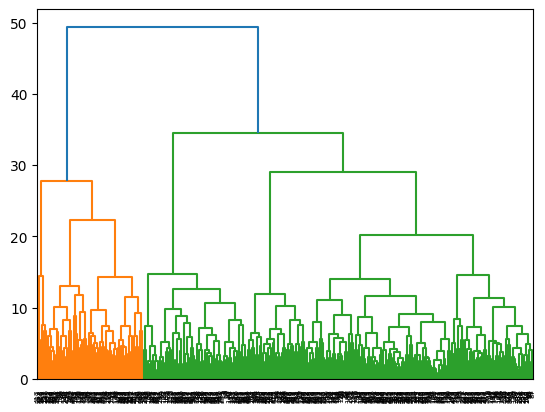

In [16]:
linked=linkage(data_prepared,method='ward')
dendrogram(linked)

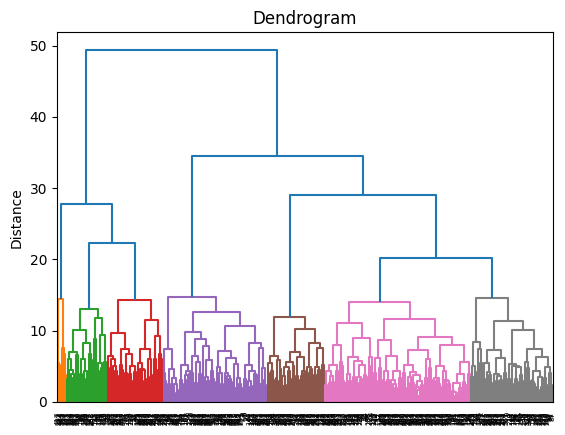

In [17]:
dendrogram(linked, 
           distance_sort='ascending', 
           color_threshold=20)   # cut tree at 20
plt.title("Dendrogram")
plt.ylabel("Distance")
plt.show()

In [18]:
h_clusters = fcluster(linked, 
                      t=5, 
                      criterion='maxclust')
raw_data['h_clusters'] = h_clusters
raw_data.h_clusters = raw_data.h_clusters.astype('category')
raw_data.h_clusters.value_counts(sort = False)

h_clusters
1     10
2     97
3    105
4     58
5    230
Name: count, dtype: int64

In [19]:
raw_data.drop(['id','age','marital_status','education'],axis = 1)\
    .groupby(['h_clusters'], observed=True)\
    .aggregate('mean')\
    .round(2)\
    .T

h_clusters,1,2,3,4,5
performance,1.10,3.88,4.71,4.46,4.39
fees_commissions,2.89,3.67,4.10,3.88,3.68
depth_of_products,1.22,3.28,4.61,3.89,3.67
ability_resolve_problems,1.30,3.47,4.77,4.14,3.82
online_services,1.80,2.61,3.45,2.37,2.32
choice_of_providers,1.00,3.04,4.28,3.23,3.22
quality_of_advice,1.30,3.45,4.94,4.45,4.39
knowledge_of_reps,1.20,3.32,4.93,4.41,4.35
rep_knowing_your_needs,1.90,2.86,4.93,4.17,4.11
professional_services,1.20,2.56,4.37,3.44,3.44


In [20]:
raw_data.drop(['id','age','marital_status','education'],axis = 1)\
    .groupby(['h_clusters'], observed=True)\
    .aggregate('mean')\
    .round(2)\
    .T

h_clusters,1,2,3,4,5
performance,1.10,3.88,4.71,4.46,4.39
fees_commissions,2.89,3.67,4.10,3.88,3.68
depth_of_products,1.22,3.28,4.61,3.89,3.67
ability_resolve_problems,1.30,3.47,4.77,4.14,3.82
online_services,1.80,2.61,3.45,2.37,2.32
choice_of_providers,1.00,3.04,4.28,3.23,3.22
quality_of_advice,1.30,3.45,4.94,4.45,4.39
knowledge_of_reps,1.20,3.32,4.93,4.41,4.35
rep_knowing_your_needs,1.90,2.86,4.93,4.17,4.11
professional_services,1.20,2.56,4.37,3.44,3.44


In [21]:
for var in ['age','marital_status','education']:
    ct = pd.crosstab(raw_data['h_clusters'],raw_data[var], normalize='index')
    ct = (ct*100).round(2)
    print('------------------------------')
    print(ct)

------------------------------
age           1.0    2.0    3.0    4.0
h_clusters                            
1            0.00  30.00  30.00  40.00
2           23.40  21.28  27.66  27.66
3           17.48  34.95  33.01  14.56
4            7.27  23.64  32.73  36.36
5            5.48  25.11  38.36  31.05
------------------------------
marital_status     1.0     2.0
h_clusters                    
1               100.00    0.00
2                95.74    4.26
3                96.12    3.88
4                 0.00  100.00
5               100.00    0.00
------------------------------
education     1.0    2.0    3.0    4.0    5.0    6.0
h_clusters                                          
1           20.00   0.00  20.00   0.00  30.00  30.00
2            2.13  13.83  28.72  11.70  28.72  14.89
3            4.90  19.61  31.37  14.71  19.61   9.80
4           12.07  24.14  25.86  17.24  12.07   8.62
5           11.61  18.75  28.12   6.70  16.52  18.30
